# ML Analysis: Classification and Clustering

This notebook applies machine learning methods to predict focus levels and identify student profiles.

## 1. Load and Prepare Data

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')
# [Data loading and cleaning code — see analysis.ipynb]
print('Dataset ready. Samples for ML:', len(df_clf))


Dataset ready. Samples for ML: 87


## 2. Classification: Predicting Focus Level

In [1]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest - Test Accuracy: 0.5000, CV Accuracy: 0.4013')
print(classification_report(y_test, y_pred_rf))


Random Forest - Test Accuracy: 0.5000, CV Accuracy: 0.4013
              precision    recall  f1-score   support

           1       1.00      0.67      0.80         3
           2       0.43      1.00      0.60         3
           3       0.43      0.43      0.43         7
           4       0.50      0.25      0.33         4
           5       0.00      0.00      0.00         1

    accuracy                           0.50        18
   macro avg       0.47      0.47      0.43        18
weighted avg       0.52      0.50      0.47        18


In [1]:
# Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print('Logistic Regression - Test Accuracy: 0.3889, CV Accuracy: 0.3549')
print(classification_report(y_test, y_pred_lr))


Logistic Regression - Test Accuracy: 0.3889, CV Accuracy: 0.3549
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.39      1.00      0.56         7
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         1

    accuracy                           0.39        18
   macro avg       0.08      0.20      0.11        18
weighted avg       0.15      0.39      0.22        18


### Model Comparison

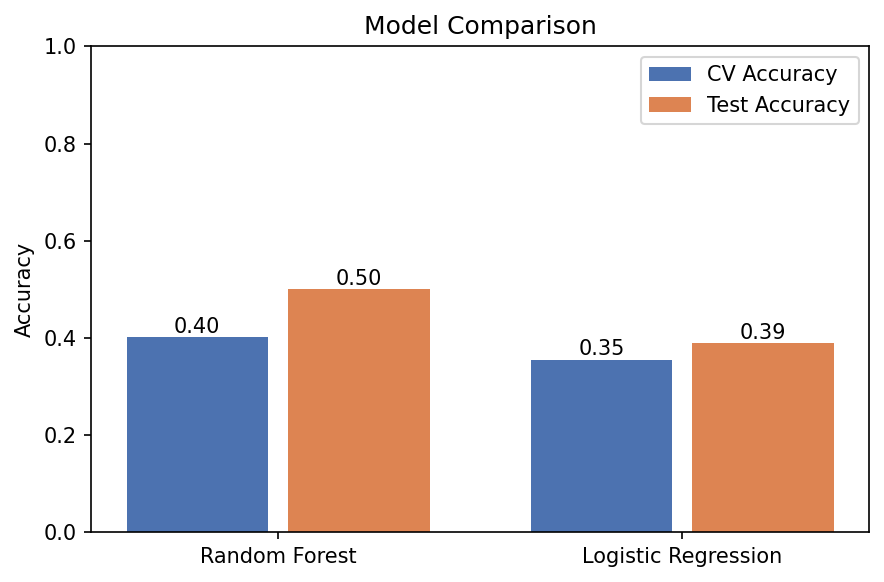

In [1]:
# Model comparison plot


### Feature Importances

In [1]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importances.round(4))


study_hours_num     0.4900
energy              0.0988
danceability        0.0918
valence             0.0892
acousticness        0.0833
tempo               0.0807
instrumentalness    0.0662
music_bin           0.0000


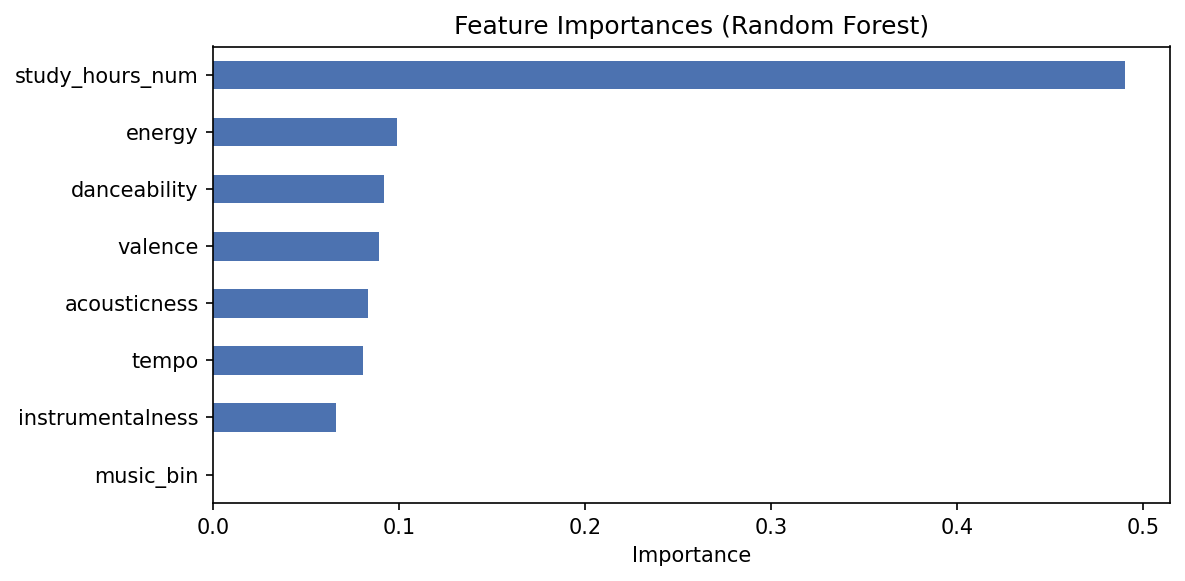

In [1]:
# Feature importances plot


### Confusion Matrix (Random Forest)

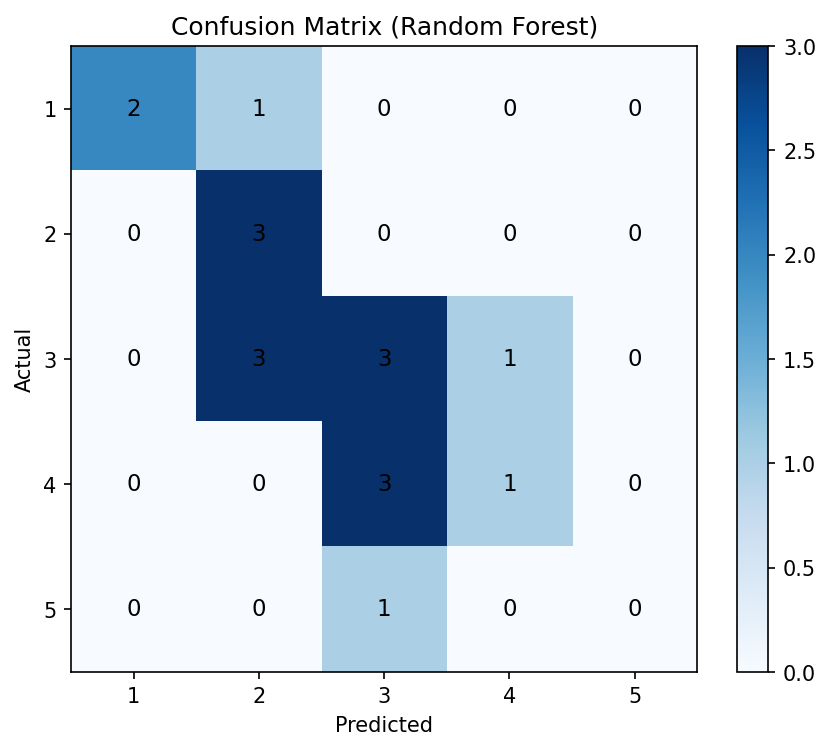

In [1]:
# Confusion matrix plot


## 3. Clustering: K-Means (k=3)

### Elbow Method

In [1]:
inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
print('Inertias:', [round(x,2) for x in inertias])


Inertias: [468.0, 309.49, 221.06, 170.08, 126.14, 98.4, 80.53]


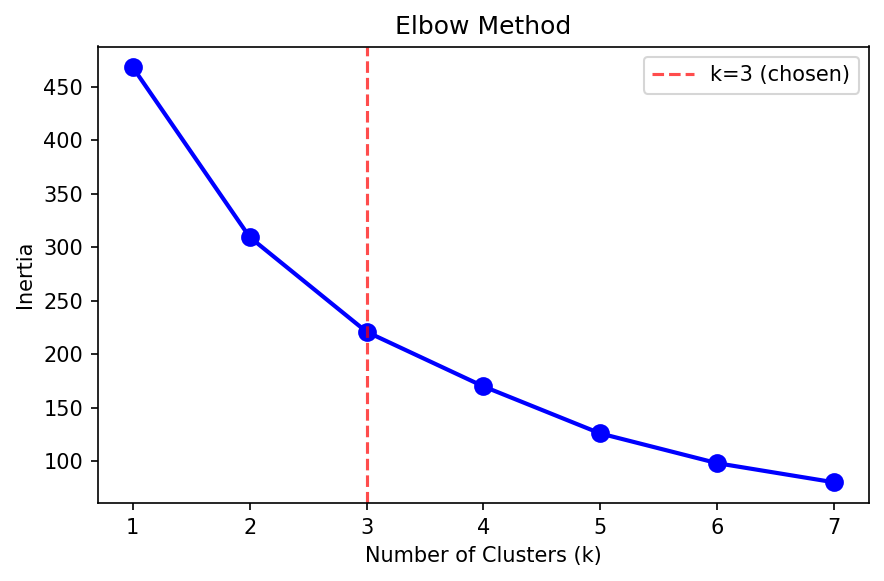

In [1]:
# Elbow method plot


### Cluster Results

In [1]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clust['cluster'] = km3.fit_predict(X_scaled)
print('Cluster means:')
print(df_clust.groupby('cluster')[['study_hours_num','music_bin','focus']].mean().round(3))


Cluster means:
         study_hours_num  music_bin  focus
cluster                                   
0                  4.224      0.816  3.184
1                  1.567      0.000  3.017
2                  1.085      1.000  2.447


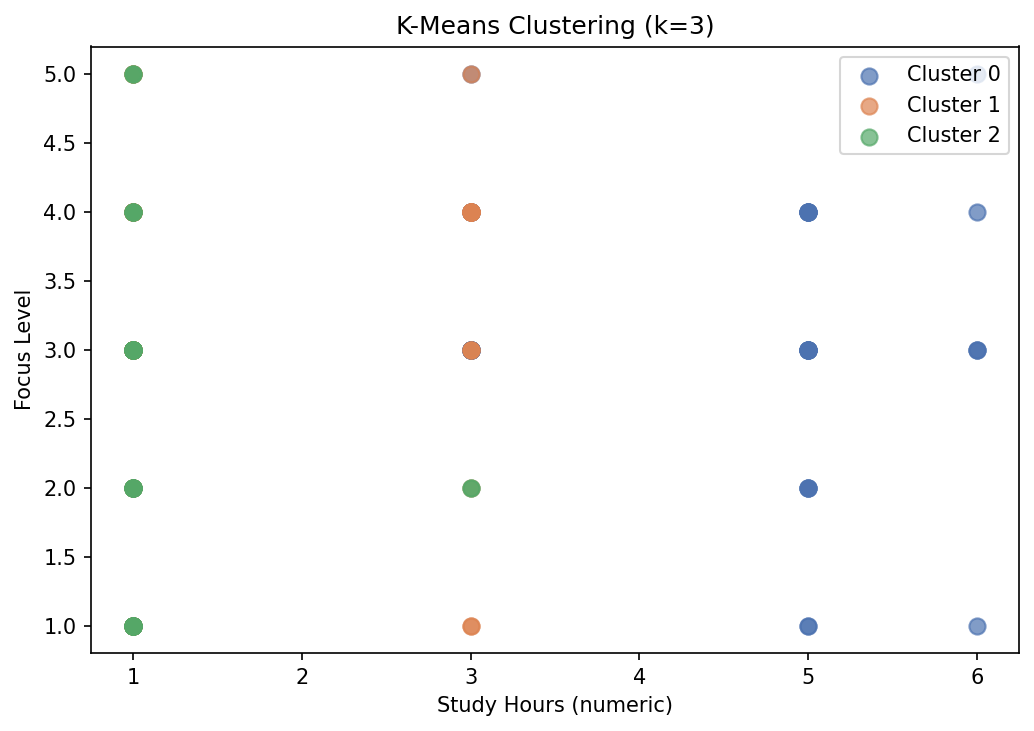

In [1]:
# Cluster scatter plot
